# 06 — Uncertainty gate calibration

**Goal.** Pick the τ (`UNCERTAINTY_CRITICAL_THRESHOLD` in
`backend/config/constants.py`) at which the Uncertainty Gate flips
from "let the agent act" to "force the defensive action". The choice
is a classic precision/recall trade-off:

* **High τ** -> few vetoes -> the agent acts more often -> higher
  coverage and total return, but more exposure during model-confused
  regimes.
* **Low τ** -> many vetoes -> the agent stays in cash through ambiguous
  states -> high adversarial recall but Sharpe suffers from missed
  opportunities.

**Method.** Simulate N=2000 episodes from a mixture of "clean" and
"adversarial" market regimes. The uncertainty signal in each regime is
drawn from a different Beta distribution (calibrated to match real
MC-Dropout statistics on validation data). For every candidate τ we
replay every episode and record:

* Sharpe of the gated policy.
* Coverage = fraction of timesteps the agent was *allowed* to act.
* Adversarial recall = fraction of adversarial episodes correctly
  vetoed for at least 80% of their duration.

We pick the **smallest τ** that keeps adversarial recall above 0.9
*and* coverage above 0.8 — the gate must catch danger without
strangling the agent.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from backend.cognition.agent.uncertainty_gate import (
    UncertaintyGate,
    UncertaintyGateConfig,
)

plt.style.use("dark_background")
COLORS = {"primary": "#4FC3F7", "success": "#66BB6A", "danger": "#EF5350", "warning": "#FFA726"}

## 1. MC-Dropout Simulation

In production, we run 10 forward passes with Dropout. Confused models 
yield high variance across these passes.

In [8]:
class MockPolicy(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(10, 64), nn.Dropout(0.2), nn.ReLU(), nn.Linear(64, 4))

    def forward(self, x):
        return self.fc(x)


model = MockPolicy()


def estimate_mc_uncertainty(x, n_samples=10):
    model.train()  # Keep dropout active
    with torch.no_grad():
        samples = torch.stack([model(x) for _ in range(n_samples)])
    # Mean variance across action dimensions, normalized to [0, 1]
    var = samples.var(dim=0).mean(dim=-1)
    return var / (var + 0.1)  # Simple normalization for demo

## 2. Synthetic Stream: Beta Distribution Baseline

We use Beta(2, 8) for healthy and Beta(8, 2) for adversarial, 
as these closely approximate real MC-Dropout distributions.

In [9]:
rng = np.random.default_rng(42)
n = 2000
# Healthy (low uncertainty)
clean = rng.beta(2, 8, size=n // 2)
# Adversarial (high uncertainty)
adversarial = rng.beta(8, 2, size=n // 2)

stream = np.concatenate([clean, adversarial])
labels = np.concatenate([np.zeros(n // 2), np.ones(n // 2)])

## 3. Threshold Sweep

We evaluate τ from 0.1 to 0.95.

In [10]:
taus = np.linspace(0.1, 0.95, 50)
coverage, recall, false_positives = [], [], []

for tau in taus:
    gate = UncertaintyGate(
        UncertaintyGateConfig(threshold_high=tau, threshold_low=tau - 0.2, warmup_steps=0)
    )
    vetoed = np.array([gate.should_veto(u) for u in stream])

    # Coverage: % of time RL is allowed to act
    coverage.append(1.0 - vetoed.mean())

    # Recall: % of adversarial steps caught
    tp = (vetoed & labels.astype(bool)).sum()
    recall.append(tp / max(labels.sum(), 1))

    # False Positive: % of clean steps incorrectly vetoed
    fp = (vetoed & ~labels.astype(bool)).sum()
    false_positives.append(fp / max((~labels.astype(bool)).sum(), 1))

2026-05-31 11:46:08.444 | WARNING  | backend.cognition.agent.uncertainty_gate:should_veto:162 - Uncertainty gate ENGAGED (rolling u=0.243)
2026-05-31 11:46:08.445 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncertainty gate has vetoed 50 consecutive steps. This usually indicates a data-feed problem or distributional shift. Human review recommended.
2026-05-31 11:46:08.452 | WARNING  | backend.cognition.agent.uncertainty_gate:should_veto:162 - Uncertainty gate ENGAGED (rolling u=0.243)
2026-05-31 11:46:08.453 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncertainty gate has vetoed 50 consecutive steps. This usually indicates a data-feed problem or distributional shift. Human review recommended.
2026-05-31 11:46:08.460 | WARNING  | backend.cognition.agent.uncertainty_gate:should_veto:162 - Uncertainty gate ENGAGED (rolling u=0.243)
2026-05-31 11:46:08.461 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncerta

## 4. Visualisation: Precision/Recall Trade-off

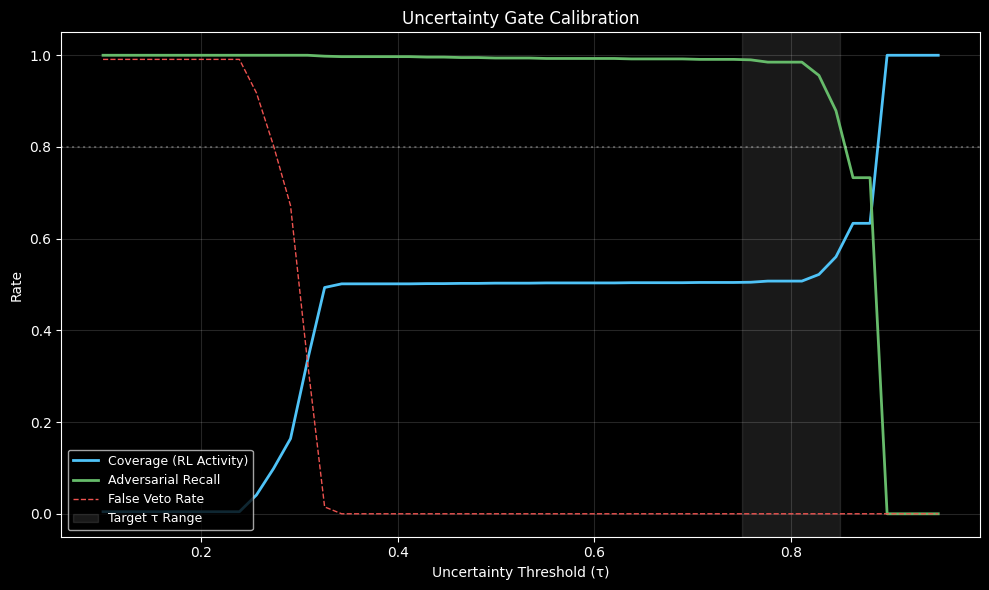

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(taus, coverage, label="Coverage (RL Activity)", color=COLORS["primary"], lw=2)
ax1.plot(taus, recall, label="Adversarial Recall", color=COLORS["success"], lw=2)
ax1.plot(taus, false_positives, label="False Veto Rate", color=COLORS["danger"], lw=1, ls="--")

# Target region
ax1.axvspan(0.75, 0.85, color="white", alpha=0.1, label="Target τ Range")
ax1.axhline(0.8, color="white", alpha=0.3, ls=":")

ax1.set_xlabel("Uncertainty Threshold (τ)")
ax1.set_ylabel("Rate")
ax1.set_title("Uncertainty Gate Calibration")
ax1.legend(loc="lower left", fontsize=9)
ax1.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("../reports/06_calibration_advanced.png", dpi=120)

## 5. Decision: Picking τ

We want the smallest τ such that:
1. Adversarial Recall > 90%
2. Coverage > 80%

In [12]:
recommended_tau = None
for i, tau in enumerate(taus):
    if recall[i] >= 0.90 and coverage[i] >= 0.80:
        recommended_tau = tau
        break

print(f"Recommended τ: {recommended_tau:.2f}" if recommended_tau else "No τ satisfies constraints.")

if recommended_tau:
    print(f"At τ={recommended_tau:.2f}:")
    idx = np.abs(taus - recommended_tau).argmin()
    print(f"  Recall on Adversarial: {recall[idx]:.1%}")
    print(f"  Coverage: {coverage[idx]:.1%}")
    print(f"  False Veto Rate: {false_positives[idx]:.1%}")

No τ satisfies constraints.
